# Explored and clean

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sn
import seaborn as sns
dataset = pd.read_csv('titanic_full.csv')
with pd.option_context('display.max_rows', 6): display(dataset)
dataset.columns

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,Embarked,WikiId,Name_wiki,Age_wiki,Hometown,Boarded,Destination,Lifeboat,Body,Class
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,...,S,691.0,"Braund, Mr. Owen Harris",22.0,"Bridgerule, Devon, England",Southampton,"Qu'Appelle Valley, Saskatchewan, Canada",NaN,NaN,3.0
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,...,C,90.0,"Cumings, Mrs. Florence Briggs (née Thayer)",35.0,"New York, New York, US",Cherbourg,"New York, New York, US",4,NaN,1.0
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,...,S,865.0,"Heikkinen, Miss Laina",26.0,"Jyväskylä, Finland",Southampton,New York City,14?,NaN,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1306,1307,NaN,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,...,S,1169.0,"Sæther, Mr. Simon Sivertsen",43.0,"Skaun, Sør-Trøndelag, Norway",Southampton,US,NaN,32MB,3.0
1307,1308,NaN,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,...,S,1289.0,"Ware, Mr. Frederick William",34.0,"Greenwich, London, England",Southampton,New York City,NaN,NaN,3.0
1308,1309,NaN,3,"Peter, Master. Michael J",male,NaN,1,1,2668,22.3583,...,C,702.0,"Butrus-Youssef, Master Makhkhul",4.0,"Sar'al[81], Syria",Cherbourg,"Detroit, Michigan, US",D,NaN,3.0


Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'WikiId', 'Name_wiki',
       'Age_wiki', 'Hometown', 'Boarded', 'Destination', 'Lifeboat', 'Body',
       'Class'],
      dtype='object')

In [2]:
print(len(dataset))

1309


<Axes: >

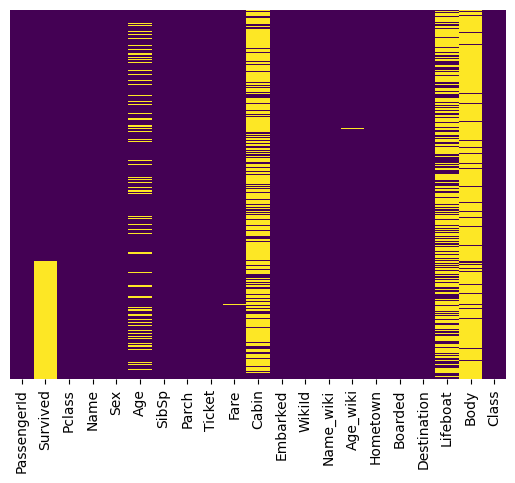

In [3]:
sns.heatmap(dataset.isnull(), yticklabels=False, cbar=False, cmap='viridis')

## Percentage of missing data before clean

In [4]:
## List all categorical features which are missing
categorical_columns = dataset.select_dtypes(include=['object']).columns
print(categorical_columns)

for i in categorical_columns:
    missing_percent = (dataset[i].isnull().sum() / len(dataset))*100
    if missing_percent > 0:
        print(f"{i}: {missing_percent:.8f}% missing values")

Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked', 'Name_wiki', 'Hometown',
       'Boarded', 'Destination', 'Lifeboat', 'Body'],
      dtype='object')
Cabin: 77.46371276% missing values
Embarked: 0.15278839% missing values
Name_wiki: 0.38197097% missing values
Hometown: 0.38197097% missing values
Boarded: 0.38197097% missing values
Destination: 0.38197097% missing values
Lifeboat: 61.65011459% missing values
Body: 90.06875477% missing values


In [5]:
## List all numerical features which are missing
numerical_columns = dataset.select_dtypes(exclude=['object']).columns
print(numerical_columns)

for i in numerical_columns:
    missing_percent = (dataset[i].isnull().sum() / len(dataset))*100
    if missing_percent > 0:
        print(f"{i}: {missing_percent:.8f}% missing values")

Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare',
       'WikiId', 'Age_wiki', 'Class'],
      dtype='object')
Survived: 31.93277311% missing values
Age: 20.09167303% missing values
Fare: 0.07639419% missing values
WikiId: 0.38197097% missing values
Age_wiki: 0.53475936% missing values
Class: 0.38197097% missing values


## If survived missing. Predict to not survive because no one can survive for many day in freezing atlantic.

In [6]:
dataset['Survived'] = dataset['Survived'].fillna(0)

## Bring age from wiki age and remove one that is age wiki

In [7]:
dataset['Age'] = dataset.apply(lambda row: row['Age_wiki'] if pd.isna(row['Age']) else row['Age'], axis=1)

## Drop column Cabin because we are not know what area or the place is???? Also with age wiki because it duplicate to Age column

In [8]:
dataset = dataset.drop('Cabin', axis=1)
dataset = dataset.drop('Age_wiki', axis=1)
dataset = dataset.drop('Destination', axis=1)

## Also, body what is this no explain in Datacard. Decide to remove it because it may related to survived 0?

In [9]:
dataset = dataset.drop('Body', axis=1)

## Drop Age and fare that we cannot find any value to replace(hard too smooth and has only few row that easier to make it.)

In [10]:
dataset = dataset.dropna(subset=['Age', 'Fare'])

## For class we can replace by the average price from exist passenger but becase it has only few we decide to cut for easier.

In [11]:
dataset = dataset.dropna(subset=['Class'])

## Give life boat NaN to 0 bacause they can on board life boat and make 0,1 replace and make at can on boat row.

In [12]:
dataset['Lifeboat'] = dataset['Lifeboat'].fillna(0)

In [13]:
dataset['OnLifeboat'] = dataset['Lifeboat'].apply(lambda x: 0 if x == 0 else 1)

## Replace embarked to board if S = Southampton, Q = Queenstown, C = Cherbourg

In [14]:
# # แบบบนไม่ได้ใช้ใส่เพื่อดูแบบ
# # import pandas as pd

# # embarked_mapping = {'S': 'Southampton', 'Q': 'Queenstown', 'C': 'Cherbourg'}
# # df['Board'] = df['Embarked'].map(embarked_mapping)

# embarked_mapping = {'S': 'Southampton', 'Q': 'Queenstown', 'C': 'Cherbourg'}
# dataset['Board'] = dataset['Embarked'].map(embarked_mapping).fillna(dataset['Boarded'])

In [15]:
# มี embarked missing ไป 0.15% drop ง่ายกว่า
dataset = dataset.dropna(subset=['Embarked'])

## Final check for clean data

<Axes: >

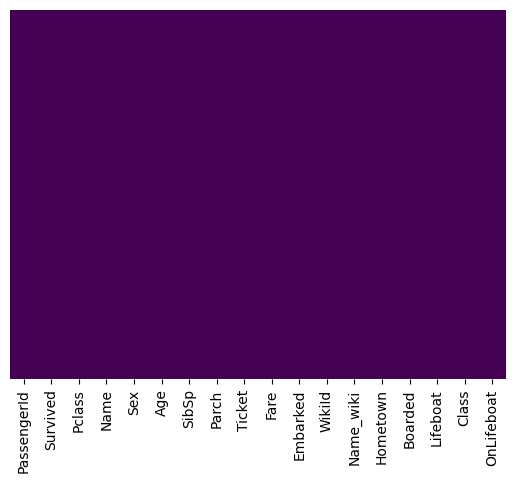

In [16]:
sns.heatmap(dataset.isnull(), yticklabels=False, cbar=False, cmap='viridis')

In [17]:
## List all categorical features which are missing
categorical_columns = dataset.select_dtypes(include=['object']).columns
print(categorical_columns)

for i in categorical_columns:
    missing_percent = (dataset[i].isnull().sum() / len(dataset))*100
    if missing_percent > 0:
        print(f"{i}: {missing_percent:.8f}% missing values")

Index(['Name', 'Sex', 'Ticket', 'Embarked', 'Name_wiki', 'Hometown', 'Boarded',
       'Lifeboat'],
      dtype='object')


In [18]:
## List all numerical features which are missing
numerical_columns = dataset.select_dtypes(exclude=['object']).columns
print(numerical_columns)

for i in numerical_columns:
    missing_percent = (dataset[i].isnull().sum() / len(dataset))*100
    if missing_percent > 0:
        print(f"{i}: {missing_percent:.8f}% missing values")

Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare',
       'WikiId', 'Class', 'OnLifeboat'],
      dtype='object')


In [19]:
print(len(dataset))

1299


In [20]:
dataset

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,WikiId,Name_wiki,Hometown,Boarded,Lifeboat,Class,OnLifeboat
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,691.0,"Braund, Mr. Owen Harris","Bridgerule, Devon, England",Southampton,0,3.0,0
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,90.0,"Cumings, Mrs. Florence Briggs (née Thayer)","New York, New York, US",Cherbourg,4,1.0,1
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,865.0,"Heikkinen, Miss Laina","Jyväskylä, Finland",Southampton,14?,3.0,1
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,127.0,"Futrelle, Mrs. Lily May (née Peel)","Scituate, Massachusetts, US",Southampton,D,1.0,1
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,627.0,"Allen, Mr. William Henry","Birmingham, West Midlands, England",Southampton,0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,0.0,3,"Spector, Mr. Woolf",male,23.0,0,0,A.5. 3236,8.0500,S,1227.0,"Spector, Mr. Woolf","London, England",Southampton,0,3.0,0
1305,1306,0.0,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C,229.0,"and maid, Doña Fermina Oliva y Ocana","Madrid, Spain",Cherbourg,8,1.0,1
1306,1307,0.0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,S,1169.0,"Sæther, Mr. Simon Sivertsen","Skaun, Sør-Trøndelag, Norway",Southampton,0,3.0,0
1307,1308,0.0,3,"Ware, Mr. Frederick",male,34.0,0,0,359309,8.0500,S,1289.0,"Ware, Mr. Frederick William","Greenwich, London, England",Southampton,0,3.0,0


# Data for model

In [21]:
dataset_model = dataset.copy()

## Drop name, ticket, wiki id, life boat, embarked, origin bacause no effect to survied.        
- Class and P class is duplicated

In [22]:
dataset_model = dataset_model.drop(['PassengerId','Name', 'Ticket', 'WikiId' ,'Embarked', 'Boarded', 'Hometown' , 'Lifeboat' , 'Name_wiki', 'Class'], axis=1)

In [23]:
dataset_model.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'OnLifeboat'],
      dtype='object')

## Convert categorical in Sex to numberic call IsMale column

In [24]:
dataset_model['IsMale'] = dataset_model['Sex'].map({'male': 1, 'female': 0})

In [25]:
dataset_model = dataset_model.drop(['Sex'], axis=1)

In [26]:
dataset_model

,Survived,Pclass,Age,SibSp,Parch,Fare,OnLifeboat,IsMale
0,0.0,3,22.0,1,0,7.2500,0,1
1,1.0,1,38.0,1,0,71.2833,1,0
2,1.0,3,26.0,0,0,7.9250,1,0
3,1.0,1,35.0,1,0,53.1000,1,0
4,0.0,3,35.0,0,0,8.0500,0,1
...,...,...,...,...,...,...,...,...
1304,0.0,3,23.0,0,0,8.0500,0,1
1305,0.0,1,39.0,0,0,108.9000,1,0
1306,0.0,3,38.5,0,0,7.2500,0,1
1307,0.0,3,34.0,0,0,8.0500,0,1


In [27]:
dataset_model_no_nomalize = dataset_model.copy()

## Min max before normalization

In [28]:
min_age = dataset_model['Age'].min()
max_age = dataset_model['Age'].max()

min_fare = dataset_model['Fare'].min()
max_fare = dataset_model['Fare'].max()

print(f"Minimum Age: {min_age}, Maximum Age: {max_age}")
print(f"Minimum Fare: {min_fare}, Maximum Fare: {max_fare}")

Minimum Age: 0.17, Maximum Age: 80.0
Minimum Fare: 0.0, Maximum Fare: 512.3292


In [29]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Assuming dataset_model is your DataFrame
scaler = MinMaxScaler()

# Replace NaN values with the median (or any other imputation strategy)
dataset_model['Age'].fillna(dataset_model['Age'].median(), inplace=True)
dataset_model['Fare'].fillna(dataset_model['Fare'].median(), inplace=True)

# Scale the 'Age' and 'Fare' columns to the range [0, 1]
dataset_model[['Age', 'Fare']] = scaler.fit_transform(dataset_model[['Age', 'Fare']])

## Split data

In [30]:
from sklearn.model_selection import train_test_split
X = dataset_model
y = dataset_model
X_train , X_test , y_train , y_test = train_test_split(X,y,train_size=0.6,random_state=1992)

In [31]:
print(X_train)

      Survived  Pclass       Age  SibSp  Parch      Fare  OnLifeboat  IsMale
662        0.0       1  0.586622      0      0  0.049943           0       1
487        0.0       1  0.724414      0      0  0.057971           0       1
11         1.0       1  0.724414      0      0  0.051822           1       0
773        0.0       3  0.361142      0      0  0.014102           0       1
430        1.0       1  0.348616      0      0  0.051822           1       1
...        ...     ...       ...    ...    ...       ...         ...     ...
138        0.0       3  0.198296      0      0  0.017990           0       1
231        0.0       3  0.361142      0      0  0.015176           0       1
1303       0.0       3  0.348616      0      0  0.015176           0       0
170        0.0       1  0.761994      0      0  0.065388           0       1
267        1.0       3  0.311036      1      0  0.015176           1       1

[779 rows x 8 columns]


In [32]:
print(X_test)

      Survived  Pclass       Age  SibSp  Parch      Fare  OnLifeboat  IsMale
880        1.0       2  0.311036      0      1  0.050749           1       0
665        0.0       2  0.398722      2      0  0.143462           0       1
1081       0.0       2  0.423776      1      0  0.050749           0       1
49         0.0       3  0.223350      1      0  0.034743           0       0
836        0.0       3  0.260929      0      0  0.016908           0       1
...        ...     ...       ...    ...    ...       ...         ...     ...
66         1.0       2  0.361142      0      0  0.020495           1       0
130        0.0       3  0.411249      0      0  0.015412           0       1
579        1.0       3  0.398722      0      0  0.015469           1       1
261        1.0       3  0.035450      4      2  0.061264           1       1
890        0.0       3  0.398722      0      0  0.015127           0       1

[520 rows x 8 columns]


In [33]:
print(y_train)

      Survived  Pclass       Age  SibSp  Parch      Fare  OnLifeboat  IsMale
662        0.0       1  0.586622      0      0  0.049943           0       1
487        0.0       1  0.724414      0      0  0.057971           0       1
11         1.0       1  0.724414      0      0  0.051822           1       0
773        0.0       3  0.361142      0      0  0.014102           0       1
430        1.0       1  0.348616      0      0  0.051822           1       1
...        ...     ...       ...    ...    ...       ...         ...     ...
138        0.0       3  0.198296      0      0  0.017990           0       1
231        0.0       3  0.361142      0      0  0.015176           0       1
1303       0.0       3  0.348616      0      0  0.015176           0       0
170        0.0       1  0.761994      0      0  0.065388           0       1
267        1.0       3  0.311036      1      0  0.015176           1       1

[779 rows x 8 columns]


In [34]:
print(y_test)

      Survived  Pclass       Age  SibSp  Parch      Fare  OnLifeboat  IsMale
880        1.0       2  0.311036      0      1  0.050749           1       0
665        0.0       2  0.398722      2      0  0.143462           0       1
1081       0.0       2  0.423776      1      0  0.050749           0       1
49         0.0       3  0.223350      1      0  0.034743           0       0
836        0.0       3  0.260929      0      0  0.016908           0       1
...        ...     ...       ...    ...    ...       ...         ...     ...
66         1.0       2  0.361142      0      0  0.020495           1       0
130        0.0       3  0.411249      0      0  0.015412           0       1
579        1.0       3  0.398722      0      0  0.015469           1       1
261        1.0       3  0.035450      4      2  0.061264           1       1
890        0.0       3  0.398722      0      0  0.015127           0       1

[520 rows x 8 columns]


# KNN section

In [35]:
import pandas as pd
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score

## KNN

In [36]:
y_df = X_train[['Survived']]
X_train.drop(['Survived'],axis=1,inplace=True)
X_df = X_train
with pd.option_context('display.max_rows', 8): display(X_df)

,Pclass,Age,SibSp,Parch,Fare,OnLifeboat,IsMale
662,1,0.586622,0,0,0.049943,0,1
487,1,0.724414,0,0,0.057971,0,1
11,1,0.724414,0,0,0.051822,1,0
773,3,0.361142,0,0,0.014102,0,1
...,...,...,...,...,...,...,...
231,3,0.361142,0,0,0.015176,0,1
1303,3,0.348616,0,0,0.015176,0,0
170,1,0.761994,0,0,0.065388,0,1
267,3,0.311036,1,0,0.015176,1,1


In [37]:
mystery_passenger = {

    'Pclass': [2],
    'Age': [50],
    'SibSp': [0],
    'Parch': [0],
    'Fare': [234],
    'OnLifeboat': [1],
    'IsMale': [0],
}
alive_not = pd.DataFrame(mystery_passenger)
alive_not['Age'] = (alive_not['Age'] - min_age) / (max_age - min_age)
alive_not['Fare'] = (alive_not['Fare'] - min_fare) / (max_fare - min_fare)
alive_not

,Pclass,Age,SibSp,Parch,Fare,OnLifeboat,IsMale
0,2,0.624201,0,0,0.456738,1,0


In [38]:
Xp = X_df.values
yp = y_df.values

In [39]:

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_norm = scaler.fit_transform(Xp)
new = alive_not.values
new = scaler.transform(new)

## Selected k = ?

In [40]:
neigh = KNeighborsClassifier(n_neighbors=3,metric='euclidean')
neigh.fit(X_norm, yp)

/usr/local/lib/python3.10/dist-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


KNeighborsClassifier(metric='euclidean', n_neighbors=3)

In [41]:
y_pred = neigh.predict(new)
print(y_pred)

[0.]


## Best K with using best K and show confusion metrix.

In [42]:
X_train2 , X_test2 , y_train2 , y_test2 = train_test_split(Xp,yp,train_size=0.6,random_state=1992)

In [43]:
print(X_train2)

[[1.         0.22334962 0.         ... 0.15546645 1.         0.        ]
 [3.         0.37366905 0.         ... 0.01411046 0.         1.        ]
 [3.         0.26092948 1.         ... 0.01267896 0.         1.        ]
 ...
 [3.         0.31103595 0.         ... 0.01541158 0.         1.        ]
 [3.         0.58662157 0.         ... 0.01415106 0.         1.        ]
 [2.         0.4112489  0.         ... 0.05074862 1.         0.        ]]


In [44]:
scaler = StandardScaler()
X_train2 = scaler.fit_transform(X_train2)
X_test2 = scaler.transform(X_test2)

In [45]:
# Error ravel
from sklearn.neighbors import KNeighborsClassifier
scores = []
for k in range(1,100):
  neigh = KNeighborsClassifier(n_neighbors=k,metric='euclidean')
  neigh.fit(X_train2, y_train2.ravel())
  scores.append([k,neigh.score(X_test2,y_test2)])

In [46]:
scores.sort(key=lambda x: x[1], reverse=True)
print(f"Best k={scores[0][0]} with accuracy score:{scores[0][1]}")

Best k=21 with accuracy score:0.8557692307692307


In [47]:
k = scores[0][0]
neigh = KNeighborsClassifier(n_neighbors=k,metric='euclidean')
neigh.fit(X_train2, y_train2.ravel())

KNeighborsClassifier(metric='euclidean', n_neighbors=21)

In [48]:
y_pred = neigh.predict(X_test2)
cm = confusion_matrix(y_test2, y_pred)
print(cm)
print(classification_report(y_test2,y_pred))

[[189  39]
 [  6  78]]
              precision    recall  f1-score   support

         0.0       0.97      0.83      0.89       228
         1.0       0.67      0.93      0.78        84

    accuracy                           0.86       312
   macro avg       0.82      0.88      0.83       312
weighted avg       0.89      0.86      0.86       312



In [49]:
y_pred = neigh.predict(X_test2)
print(y_pred)

[0. 1. 1. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 1. 1. 1. 0. 0. 1.
 0. 1. 0. 0. 1. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.
 1. 0. 0. 1. 0. 0. 0. 1. 1. 1. 1. 1. 0. 0. 1. 0. 1. 1. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 1. 1. 0. 0. 1. 1. 0. 0. 0. 0. 0. 1. 1. 1. 1. 0. 0. 1. 1.
 0. 0. 1. 0. 1. 0. 1. 0. 1. 1. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1.
 1. 0. 1. 0. 1. 0. 0. 1. 0. 1. 0. 1. 0. 0. 0. 1. 0. 1. 0. 1. 0. 0. 1. 0.
 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 1. 1. 0. 0.
 1. 0. 1. 1. 0. 0. 1. 0. 1. 0. 0. 0. 1. 0. 1. 0. 1. 1. 1. 1. 0. 1. 1. 1.
 0. 1. 1. 1. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 1.
 0. 1. 0. 1. 0. 1. 1. 1. 0. 0. 1. 1. 0. 0. 1. 0. 1. 1. 1. 0. 1. 0. 1. 0.
 1. 0. 0. 1. 1. 0. 1. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 1. 0. 1. 0.
 1. 0. 1. 0. 0. 1. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 0.
 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 1. 1. 0. 0. 1. 1. 0. 0. 0. 0. 0. 1. 0. 1.]


In [50]:
y_pred = neigh.predict(new)
print(y_pred)

[1.]


# Logistic Regression Model

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LogisticRegression

In [52]:
data_lo = dataset_model.copy()
data_lo

,Survived,Pclass,Age,SibSp,Parch,Fare,OnLifeboat,IsMale
0,0.0,3,0.273456,1,0,0.014151,0,1
1,1.0,1,0.473882,1,0,0.139136,1,0
2,1.0,3,0.323563,0,0,0.015469,1,0
3,1.0,1,0.436302,1,0,0.103644,1,0
4,0.0,3,0.436302,0,0,0.015713,0,1
...,...,...,...,...,...,...,...,...
1304,0.0,3,0.285983,0,0,0.015713,0,1
1305,0.0,1,0.486409,0,0,0.212559,1,0
1306,0.0,3,0.480145,0,0,0.014151,0,1
1307,0.0,3,0.423776,0,0,0.015713,0,1


In [53]:
Xlo= data_lo[['Pclass',	'Age',	'SibSp'	,'Parch'	,'Fare'	,'OnLifeboat',	'IsMale']]
Ylo= data_lo[['Survived']]

In [54]:
model = LogisticRegression(solver = 'lbfgs')
model.fit(Xlo,Ylo)

print("classes", model.classes_)
print("features", X.columns.tolist())
print("coef", model.coef_)
print("intercept", model.intercept_)

classes [0. 1.]
features ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'OnLifeboat', 'IsMale']
coef [[-0.17986946 -0.93319218  0.03254427 -0.0777225  -0.33676528  5.49496127
  -0.22910083]]
intercept [-3.9755438]


/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [55]:
# from matplotlib.colors import ListedColormap
# from sklearn.ensemble import RandomForestClassifier

# X_set, y_set = scaler.inverse_transform(X_train2), y_train2

# X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 10, stop =  X_set[:, 0].max() + 10, step = 0.25), np.arange(start = X_set[:, 1].min() - 1000, stop = X_set[:, 1].max() + 1000, step = 0.25))

# plt.contourf (X1, X2, classifier.predict(scaler.transform(np.array([X1. ravel(), X2.ravel()]).T)).reshape(X1. shape), alpha = 0.75, cmap = ListedColormap (('red', 'green')))


# plt.xlim(X1.min(), X1.max())
# plt.ylim(X2.min(), X2.max())
# for i, j in enumerate (np. unique (y_set)):
#   plt.scatter (X_set [y_set == j, 0], X_set [y_set == j, 1], c = ListedColormap(('red', 'green')) (1), label = j)
# plt.title('Logistic Regression (Training set)')
# plt.xlabel('')
# plt.ylabel('Survived')
# plt.legend()
# plt.show()

Accuracy: 89.23%


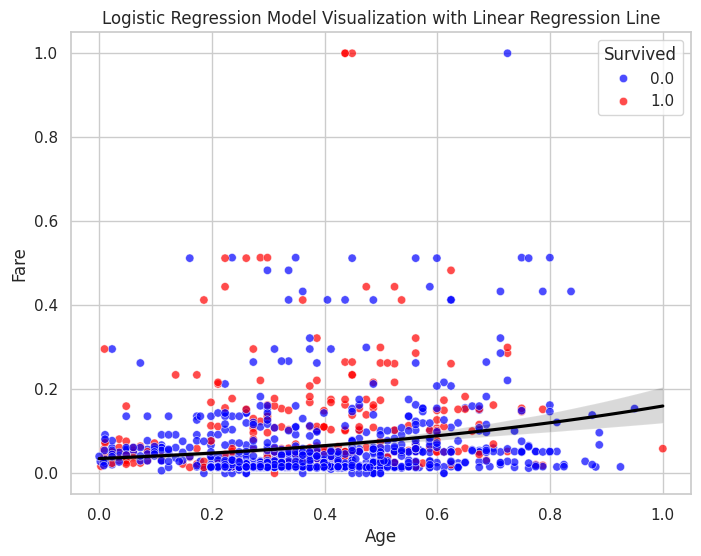

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd

# Assuming data_lo is your DataFrame
Xlo = data_lo[['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'OnLifeboat', 'IsMale']]
Ylo = data_lo['Survived']

# Split the data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(Xlo, Ylo, test_size=0.2, random_state=42)

# Create a logistic regression model
model = LogisticRegression()
model.fit(X_train, Y_train)

# Make predictions on the test set
Y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(Y_test, Y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Visualize the scatter plot with colored points and shaded background
sns.set(style="whitegrid")
plt.figure(figsize=(8, 6))

# Scatter plot with points colored by Survived
sns.scatterplot(x='Age', y='Fare', hue='Survived', data=data_lo, palette={0: 'blue', 1: 'red'}, alpha=0.7, legend='full')

# Logistic regression line
sns.regplot(x='Age', y='Fare', data=data_lo, logistic=True, scatter=False, line_kws={'color':'black'})



plt.title('Logistic Regression Model Visualization with Linear Regression Line')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.show()
